# Stampede 🐂
### Buy what's been winning, short what's been losing. Does the herd pay — and what happens when it turns?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Crash risk?: Severe](https://img.shields.io/badge/Crash_risk%3F-Severe-8b949e?style=flat-square)

This is the big one — **momentum**, the most stubbornly robust anomaly in all of finance. Rank stocks by how they've done over the past year, buy the **winners**, short the **losers**, refresh monthly. Decades of data, dozens of markets, a Nobel-adjacent literature (Jegadeesh & Titman 1993) all say the same thing: the winners keep winning, the losers keep losing, and the spread pays a large premium.

This is the desk's seventh idea from Kakushadze & Serur's *151 Trading Strategies* (strategy §3.1). We prove our tools on a synthetic market where we bake the momentum in (and a null where there's none), then run it on the real S&P 500 — where we find the famous premium has gone **faint**, and the herd, when it turns, **tramples** you: a single month down 22%, a drawdown past 60%. The signature *momentum crash*.

> 📓 **Plain-language layer.** The HAC alpha, the crash skew and the risk-managed overlay are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it; the core runs on a **synthetic** panel, so the real-S&P numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from stampede import data, momentum, strategy, decompose, extension

# Offline synthetic panel: a MOMENTUM tape (persistent relative drift -> winners keep winning) and a
# no-momentum NULL. The real S&P 500 verdict is in ../docs/results.md.
panel,  market,  truth = data.synthetic_panel(mom_strength=0.0015, seed=24)   # the momentum tape
panel0, market0, _     = data.synthetic_panel(mom_strength=0.0,    seed=24)   # the no-momentum null
print(f"{truth.n_stocks} stocks x {truth.n_bars} days | baked mom_strength={truth.mom_strength} | null=0")


150 stocks x 4032 days | baked mom_strength=0.0015 | null=0


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Do past winners keep winning? | 🟡 **In the long-run data, overwhelmingly; on the modern S&P 500, faintly** — a WML alpha of **+4.4%/yr** at *t* = **+0.9**, not significant here. |
| Can you just hold the winners? | ⚪ **Barely beats the market** (Sharpe **+0.99** vs **+0.97**). |
| What's the catch? | 🐂 **The crash.** Worst month **-22.5%**, max drawdown **-61%** — when losers rebound, the short leg detonates. |

> Desk shorthand: **Signal `WEAK` · Tradability `FRAGILE` · Crash risk? `SEVERE`** — a real premium in principle, decayed and dangerous in practice.

## 1 · The claim 📣

Sort the cross-section by the trailing 12-month return (skipping the last month, to dodge short-term reversal), and the top decile out-earns the bottom over the next month. On our synthetic momentum market, here's the forward return by momentum decile — a clean upward staircase:

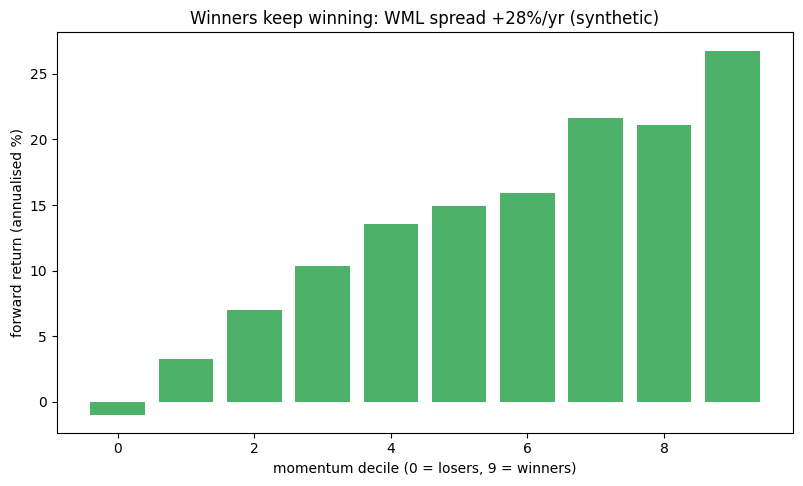

In [2]:
sp = momentum.momentum_spread(panel)
d = sp['decile_fwd_ann']
fig, ax = plt.subplots()
ax.bar(d.index, d.values, color='#2ea44f', alpha=.85)
ax.set_xlabel('momentum decile (0 = losers, 9 = winners)'); ax.set_ylabel('forward return (annualised %)')
ax.set_title(f"Winners keep winning: WML spread {sp['wml_ann_pct']:+.0f}%/yr (synthetic)")
plt.show()

## 2 · So what? 💰

Momentum is the crown jewel of factor investing — it shows up in stocks, bonds, commodities, currencies, and back to the Victorian era. If it's real and harvestable, it's one of the most valuable facts in markets. But it has a dark twin: because you're *short* the losers, a violent rebound in beaten-down names — the kind that happens at a bear-market bottom — turns the strategy inside out. That asymmetry is the whole story.

## 3 · How we'd know 🔬

Four checks:

1. **Do winners out-earn losers?** The decile profile and the WML alpha, with a *t*-stat.
2. **Can a long-only investor capture it?** Winners vs the market.
3. **What's the tail?** The crash — skew, worst months, deepest drawdown.
4. **Can it be managed?** Vol-scaling the factor. And the **null**: no persistence ⇒ no premium.

**Fragile line:** a real premium, but a catastrophic left tail and (on the modern sample) a thin, insignificant standalone return.

## 4 · The teardown 🔧

### 4a · Momentum tape vs the null
Run the WML factor on both synthetic panels.

In [3]:
for label, p in [('momentum', panel), ('no-momentum null', panel0)]:
    cmp = strategy.compare(p, cost_bps=5.0); a = decompose.capm_alpha(p, cost_bps=5.0)
    print(f"{label:18s}: WML Sharpe {cmp['wml']['sharpe']:+.2f}, alpha {a['alpha_ann_pct']:+.1f}%/yr "
          f"(HAC t {a['alpha_t']:+.1f}), turnover {cmp['turnover_ann']:.0f}x/yr")

momentum          : WML Sharpe +3.71, alpha +26.4%/yr (HAC t +14.0), turnover 5x/yr


no-momentum null  : WML Sharpe +0.28, alpha +1.4%/yr (HAC t +0.8), turnover 7x/yr


### 4b · The crash — momentum's dark twin
Even on the relatively gentle synthetic tape, the WML drawdown is the thing you feel. On the real S&P 500 it's brutal. Here's the equity curve and its underwater plot (synthetic):

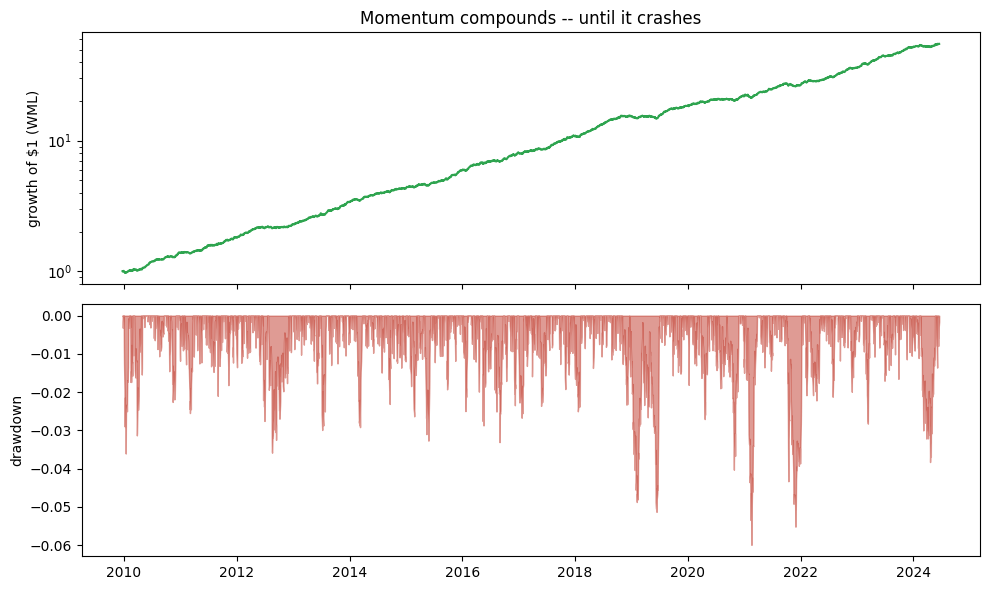

On the REAL S&P 500: worst month -22.5%, worst-5 avg -14.4%, max drawdown -61%.


In [4]:
wml = strategy.books(panel, cost_bps=5.0)['wml']
eq = (1+wml).cumprod(); dd = eq/eq.cummax()-1
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
a1.plot(eq.index, eq.values, color='#2ea44f'); a1.set_yscale('log'); a1.set_ylabel('growth of $1 (WML)')
a1.set_title('Momentum compounds -- until it crashes')
a2.fill_between(dd.index, dd.values, 0, color='#c0392b', alpha=.5); a2.set_ylabel('drawdown')
plt.tight_layout(); plt.show()
print('On the REAL S&P 500: worst month -22.5%, worst-5 avg -14.4%, max drawdown -61%.')

### 4c · On the real market — faint and crash-prone
On the current S&P 500 (quoted from [`../docs/results.md`](../docs/results.md)):

- The WML alpha is **+4.4%/yr** at *t* = **+0.9** — not distinguishable from zero on this large-cap, post-2009, survivorship-biased sample. Momentum has *decayed* in US large caps.
- Long-only winners (Sharpe **+0.99**) barely beat the market (**+0.97**).
- And the crash is real: worst month **-22.5%**, max drawdown **-61%**, with the premium swinging sub-period to sub-period (Sharpe **+0.31 → -0.40 → +0.49**).

## 5 · The verdict 🧾

- **Real in principle** — our control recovers a WML alpha at *t* ≈ 14; the long-run literature is overwhelming.
- **Faint here** — modern-S&P alpha +4.4%/yr (*t* +0.9), decayed.
- **Crash-prone** — worst month -22.5%, drawdown -61%.

> **Signal `WEAK` · Tradability `FRAGILE` · Crash risk? `SEVERE`.** The crown jewel, dimmed by decay and weighed down by a catastrophic tail.

## 6 · Could you trade it? 💸

- **The standalone premium is thin** on the investable large-cap sample (Sharpe +0.10), and you'd need to *short* the losers — the hard-to-borrow, beaten-down names.
- **The crash is the real cost.** A -61% drawdown ends most books; a single -22.5% month ends most careers.
- **It turns over fast** (the winners list churns), so costs compound.

> Tradability **`FRAGILE`**; the crash is `SEVERE` — but the worked complement ([`../docs/extension.md`](../docs/extension.md)) shows it's the *manageable* part.

## 7 · Going further 🚪

- **Risk-managed momentum** (beat 7 of the quants notebook + [`../docs/extension.md`](../docs/extension.md)): the crashes cluster when the factor's own vol is high, so vol-scaling it (the [Study 16](../../16-storm-shy/) overlay) cuts the drawdown from **-61% to -32%** and lifts the Sharpe to **+0.16**.
- **Residual momentum** (§3.7) — strip the market/factor exposure and momentum on the residuals is cleaner and less crash-prone; the desk's next candidate.
- **Longer, delisted-inclusive data.** The famous premium lives in the broad, all-cap, pre-2010 cross-section; a CRSP-style panel would show it alive where our large-cap window is faint, and date the decay.

PRs welcome — resurrect the premium on honest long-run data, or push the crash-management further.